# Data Wrangling

Load & transform NBA dataset

Ensure the two datasets are located in folder called data (or update load filepath)

### Import & Load Data

In [1]:
# Imports
import pandas as pd
import polars as pl
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt


In [2]:
# Load raw csv data
df_shots = pl.read_csv("data/shotdetail_2024.csv", try_parse_dates=True)
df_cdnnba = pl.read_csv("data/cdnnba_2024.csv", try_parse_dates=True)
df_shots.head(5)

GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,EVENT_TYPE,ACTION_TYPE,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM
str,i64,i64,i64,str,i64,str,i64,i64,i64,str,str,str,str,str,str,i64,i64,i64,i64,i64,i64,str,str
"""Shot Chart Detail""",22400001,7,1642258,"""Zaccharie Risacher""",1610612737,"""Atlanta Hawks""",1,11,43,"""Missed Shot""","""Jump Shot""","""3PT Field Goal""","""Above the Break 3""","""Left Side Center(LC)""","""24+ ft.""",26,-168,205,1,0,20241112,"""BOS""","""ATL"""
"""Shot Chart Detail""",22400001,10,1630552,"""Jalen Johnson""",1610612737,"""Atlanta Hawks""",1,11,38,"""Missed Shot""","""Driving Floating Bank Jump Sho…","""2PT Field Goal""","""Mid-Range""","""Left Side(L)""","""8-16 ft.""",13,-136,-1,1,0,20241112,"""BOS""","""ATL"""
"""Shot Chart Detail""",22400001,21,1630552,"""Jalen Johnson""",1610612737,"""Atlanta Hawks""",1,10,50,"""Made Shot""","""Jump Shot""","""3PT Field Goal""","""Above the Break 3""","""Right Side Center(RC)""","""24+ ft.""",25,157,203,1,1,20241112,"""BOS""","""ATL"""
"""Shot Chart Detail""",22400001,34,1630811,"""Keaton Wallace""",1610612737,"""Atlanta Hawks""",1,9,47,"""Missed Shot""","""Jump Shot""","""3PT Field Goal""","""Above the Break 3""","""Left Side Center(LC)""","""24+ ft.""",25,-176,184,1,0,20241112,"""BOS""","""ATL"""
"""Shot Chart Detail""",22400001,36,203991,"""Clint Capela""",1610612737,"""Atlanta Hawks""",1,9,44,"""Made Shot""","""Putback Layup Shot""","""2PT Field Goal""","""Restricted Area""","""Center(C)""","""Less Than 8 ft.""",2,-25,8,1,1,20241112,"""BOS""","""ATL"""


### Exploration

In [3]:
df_cdnnba.head(5)

actionNumber,clock,timeActual,period,periodType,actionType,subType,qualifiers,personId,x,y,possession,scoreHome,scoreAway,edited,orderNumber,isTargetScoreLastPeriod,xLegacy,yLegacy,isFieldGoal,side,description,personIdsFilter,teamId,teamTricode,descriptor,jumpBallRecoveredName,jumpBallRecoverdPersonId,playerName,playerNameI,jumpBallWonPlayerName,jumpBallWonPersonId,jumpBallLostPlayerName,jumpBallLostPersonId,area,areaDetail,shotDistance,shotResult,blockPlayerName,blockPersonId,shotActionNumber,reboundTotal,reboundDefensiveTotal,reboundOffensiveTotal,officialId,turnoverTotal,stealPlayerName,stealPersonId,pointsTotal,assistPlayerNameInitial,assistPersonId,assistTotal,foulPersonalTotal,foulTechnicalTotal,foulDrawnPlayerName,foulDrawnPersonId,gameId
i64,str,"datetime[μs, UTC]",i64,str,str,str,str,i64,f64,f64,i64,i64,i64,"datetime[μs, UTC]",i64,bool,i64,i64,i64,str,str,str,i64,str,str,str,i64,str,str,str,i64,str,i64,str,str,f64,str,str,i64,i64,i64,i64,i64,i64,i64,str,i64,i64,str,i64,i64,i64,i64,str,i64,i64
2,"""PT12M00.00S""",2024-11-13 00:10:24.900 UTC,1,"""REGULAR""","""period""","""start""","""""",0,null,null,0,0,0,2024-11-13 00:10:24 UTC,20000,false,null,null,0,null,"""Period Start""","""""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,22400001
4,"""PT11M58.00S""",2024-11-13 00:10:26.800 UTC,1,"""REGULAR""","""jumpball""","""recovered""","""""",1630811,null,null,1610612737,0,0,2024-11-13 00:10:26 UTC,40000,false,null,null,0,null,"""Jump Ball C. Capela vs. A. Hor…","""1630811, 203991, 201143""",1610612737,"""ATL""","""startperiod""","""K. Wallace""",1630811,"""Wallace""","""K. Wallace""","""Capela""",203991,"""Horford""",201143,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,22400001
7,"""PT11M43.00S""",2024-11-13 00:10:40 UTC,1,"""REGULAR""","""3pt""","""Jump Shot""","""""",1642258,27.414586,83.578431,1610612737,0,0,2024-11-13 00:10:47 UTC,70000,false,-168,205,1,"""left""","""MISS Z. Risacher 26' 3PT - blo…","""1642258, 1628369""",1610612737,"""ATL""",null,null,null,"""Risacher""","""Z. Risacher""",null,null,null,null,"""Above the Break 3""","""24+ Left Center""",26.51,"""Missed""","""Tatum""",1628369,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,22400001
8,"""PT11M43.00S""",2024-11-13 00:10:40 UTC,1,"""REGULAR""","""block""","""""","""""",1628369,null,null,1610612737,0,0,2024-11-13 00:10:42 UTC,80000,false,null,null,0,null,"""J. Tatum BLOCK (1 BLK)""","""1628369""",1610612738,"""BOS""",null,null,null,"""Tatum""","""J. Tatum""",null,null,null,null,"""Above the Break 3""","""24+ Left Center""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,22400001
9,"""PT11M42.00S""",2024-11-13 00:10:41 UTC,1,"""REGULAR""","""rebound""","""offensive""","""""",1642258,null,null,1610612737,0,0,2024-11-13 00:10:47 UTC,90000,false,null,null,0,null,"""Z. Risacher REBOUND (Off:1 Def…","""1642258""",1610612737,"""ATL""",null,null,null,"""Risacher""","""Z. Risacher""",null,null,null,null,"""Above the Break 3""","""24+ Left Center""",null,null,null,null,7,1,0,1,null,null,null,null,null,null,null,null,null,null,null,null,22400001


In [4]:
df_cdnnba.dtypes

[Int64,
 String,
 Datetime(time_unit='us', time_zone='UTC'),
 Int64,
 String,
 String,
 String,
 String,
 Int64,
 Float64,
 Float64,
 Int64,
 Int64,
 Int64,
 Datetime(time_unit='us', time_zone='UTC'),
 Int64,
 Boolean,
 Int64,
 Int64,
 Int64,
 String,
 String,
 String,
 Int64,
 String,
 String,
 String,
 Int64,
 String,
 String,
 String,
 Int64,
 String,
 Int64,
 String,
 String,
 Float64,
 String,
 String,
 Int64,
 Int64,
 Int64,
 Int64,
 Int64,
 Int64,
 Int64,
 String,
 Int64,
 Int64,
 String,
 Int64,
 Int64,
 Int64,
 Int64,
 String,
 Int64,
 Int64]

In [36]:
# Merge two dataframes
df_merged = df_shots.join(df_cdnnba, how='left', left_on=['GAME_ID', 'GAME_EVENT_ID'], right_on=['gameId', 'actionNumber'])
df_merged = df_merged.with_columns(pl.concat_str([pl.col('GAME_ID'), pl.col('GAME_EVENT_ID')], separator="_").alias('Record_Id'))
df_merged.head(5)

GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,EVENT_TYPE,ACTION_TYPE,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM,clock,timeActual,period,periodType,actionType,subType,qualifiers,personId,x,y,possession,scoreHome,scoreAway,…,side,description,personIdsFilter,teamId,teamTricode,descriptor,jumpBallRecoveredName,jumpBallRecoverdPersonId,playerName,playerNameI,jumpBallWonPlayerName,jumpBallWonPersonId,jumpBallLostPlayerName,jumpBallLostPersonId,area,areaDetail,shotDistance,shotResult,blockPlayerName,blockPersonId,shotActionNumber,reboundTotal,reboundDefensiveTotal,reboundOffensiveTotal,officialId,turnoverTotal,stealPlayerName,stealPersonId,pointsTotal,assistPlayerNameInitial,assistPersonId,assistTotal,foulPersonalTotal,foulTechnicalTotal,foulDrawnPlayerName,foulDrawnPersonId,Record_Id
str,i64,i64,i64,str,i64,str,i64,i64,i64,str,str,str,str,str,str,i64,i64,i64,i64,i64,i64,str,str,str,"datetime[μs, UTC]",i64,str,str,str,str,i64,f64,f64,i64,i64,i64,…,str,str,str,i64,str,str,str,i64,str,str,str,i64,str,i64,str,str,f64,str,str,i64,i64,i64,i64,i64,i64,i64,str,i64,i64,str,i64,i64,i64,i64,str,i64,str
"""Shot Chart Detail""",22400001,7,1642258,"""Zaccharie Risacher""",1610612737,"""Atlanta Hawks""",1,11,43,"""Missed Shot""","""Jump Shot""","""3PT Field Goal""","""Above the Break 3""","""Left Side Center(LC)""","""24+ ft.""",26,-168,205,1,0,20241112,"""BOS""","""ATL""","""PT11M43.00S""",2024-11-13 00:10:40 UTC,1,"""REGULAR""","""3pt""","""Jump Shot""","""""",1642258,27.414586,83.578431,1610612737,0,0,…,"""left""","""MISS Z. Risacher 26' 3PT - blo…","""1642258, 1628369""",1610612737,"""ATL""",null,null,null,"""Risacher""","""Z. Risacher""",null,null,null,null,"""Above the Break 3""","""24+ Left Center""",26.51,"""Missed""","""Tatum""",1628369,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""22400001_7"""
"""Shot Chart Detail""",22400001,10,1630552,"""Jalen Johnson""",1610612737,"""Atlanta Hawks""",1,11,38,"""Missed Shot""","""Driving Floating Bank Jump Sho…","""2PT Field Goal""","""Mid-Range""","""Left Side(L)""","""8-16 ft.""",13,-136,-1,1,0,20241112,"""BOS""","""ATL""","""PT11M38.00S""",2024-11-13 00:10:46 UTC,1,"""REGULAR""","""2pt""","""Jump Shot""","""2ndchance""",1630552,5.469777,77.205882,1610612737,0,0,…,"""left""","""MISS J. Johnson 13' driving fl…","""1630552""",1610612737,"""ATL""","""driving floating bank""",null,null,"""Johnson""","""J. Johnson""",null,null,null,null,"""Mid-Range""","""8-16 Left""",13.6,"""Missed""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""22400001_10"""
"""Shot Chart Detail""",22400001,21,1630552,"""Jalen Johnson""",1610612737,"""Atlanta Hawks""",1,10,50,"""Made Shot""","""Jump Shot""","""3PT Field Goal""","""Above the Break 3""","""Right Side Center(RC)""","""24+ ft.""",25,157,203,1,1,20241112,"""BOS""","""ATL""","""PT10M50.00S""",2024-11-13 00:11:45.500 UTC,1,"""REGULAR""","""3pt""","""Jump Shot""","""fromturnover""",1630552,27.151774,18.627451,1610612737,0,3,…,"""left""","""J. Johnson 25' 3PT (3 PTS) (K…","""1630552, 1630811""",1610612737,"""ATL""",null,null,null,"""Johnson""","""J. Johnson""",null,null,null,null,"""Above the Break 3""","""24+ Right Center""",25.63,"""Made""",null,null,null,null,null,null,null,null,null,null,3,"""K. Wallace""",1630811,1,null,null,null,null,"""22400001_21"""
"""Shot Chart Detail""",22400001,34,1630811,"""Keaton Wallace""",1610612737,"""Atlanta Hawks""",1,9,47,"""Missed Shot""","""Jump Shot""","""3PT Field Goal""","""Above the Break 3""","""Left Side Center(LC)""","""24+ ft.""",25,-176,184,1,0,20241112,"""BOS""","""ATL""","""PT09M47.00S""",2024-11-13 00:13:42.600 UTC,1,"""REGULAR""","""3pt""","""Jump Shot""","""""",1630811,25.180683,85.294118,1610612737,3,3,…,"""left""","""MISS K. Wallace 25' 3PT""","""1630811""",1610612737,"""ATL""",nu

In [6]:
# Check merge logic correct & identify discrepancies

# Display Team ID discrepancies
team_discrepancies = df_merged.filter(pl.col("TEAM_ID") != pl.col("teamId"))
team_discrepancies

GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,EVENT_TYPE,ACTION_TYPE,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM,clock,timeActual,period,periodType,actionType,subType,qualifiers,personId,x,y,possession,scoreHome,scoreAway,…,isFieldGoal,side,description,personIdsFilter,teamId,teamTricode,descriptor,jumpBallRecoveredName,jumpBallRecoverdPersonId,playerName,playerNameI,jumpBallWonPlayerName,jumpBallWonPersonId,jumpBallLostPlayerName,jumpBallLostPersonId,area,areaDetail,shotDistance,shotResult,blockPlayerName,blockPersonId,shotActionNumber,reboundTotal,reboundDefensiveTotal,reboundOffensiveTotal,officialId,turnoverTotal,stealPlayerName,stealPersonId,pointsTotal,assistPlayerNameInitial,assistPersonId,assistTotal,foulPersonalTotal,foulTechnicalTotal,foulDrawnPlayerName,foulDrawnPersonId
str,i64,i64,i64,str,i64,str,i64,i64,i64,str,str,str,str,str,str,i64,i64,i64,i64,i64,i64,str,str,str,"datetime[μs, UTC]",i64,str,str,str,str,i64,f64,f64,i64,i64,i64,…,i64,str,str,str,i64,str,str,str,i64,str,str,str,i64,str,i64,str,str,f64,str,str,i64,i64,i64,i64,i64,i64,i64,str,i64,i64,str,i64,i64,i64,i64,str,i64


In [9]:
# Display Player ID discrepancies
player_discrepancies = df_merged.filter(pl.col("PLAYER_ID") != pl.col("personId"))
player_discrepancies

GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,EVENT_TYPE,ACTION_TYPE,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM,clock,timeActual,period,periodType,actionType,subType,qualifiers,personId,x,y,possession,scoreHome,scoreAway,…,isFieldGoal,side,description,personIdsFilter,teamId,teamTricode,descriptor,jumpBallRecoveredName,jumpBallRecoverdPersonId,playerName,playerNameI,jumpBallWonPlayerName,jumpBallWonPersonId,jumpBallLostPlayerName,jumpBallLostPersonId,area,areaDetail,shotDistance,shotResult,blockPlayerName,blockPersonId,shotActionNumber,reboundTotal,reboundDefensiveTotal,reboundOffensiveTotal,officialId,turnoverTotal,stealPlayerName,stealPersonId,pointsTotal,assistPlayerNameInitial,assistPersonId,assistTotal,foulPersonalTotal,foulTechnicalTotal,foulDrawnPlayerName,foulDrawnPersonId
str,i64,i64,i64,str,i64,str,i64,i64,i64,str,str,str,str,str,str,i64,i64,i64,i64,i64,i64,str,str,str,"datetime[μs, UTC]",i64,str,str,str,str,i64,f64,f64,i64,i64,i64,…,i64,str,str,str,i64,str,str,str,i64,str,str,str,i64,str,i64,str,str,f64,str,str,i64,i64,i64,i64,i64,i64,i64,str,i64,i64,str,i64,i64,i64,i64,str,i64
"""Shot Chart Detail""",22400912,368,1641878,"""Damion Baugh""",1610612766,"""Charlotte Hornets""",3,9,46,"""Missed Shot""","""Driving Finger Roll Layup Shot""","""2PT Field Goal""","""Restricted Area""","""Center(C)""","""Less Than 8 ft.""",1,13,5,1,0,20250308,"""CHA""","""BKN""","""PT09M46.00S""",2025-03-09 00:26:20.600 UTC,3,"""REGULAR""","""2pt""","""Layup""","""pointsinthepaint""",1641733,6.126807,47.303922,1610612766,48,63,…,1,"""left""","""MISS N. Smith Jr. driving fing…","""1641733""",1610612766,"""CHA""","""driving finger roll""",null,null,"""Smith Jr.""","""N. Smith Jr.""",null,null,null,null,"""Restricted Area""","""0-8 Center""",1.44,"""Missed""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""Shot Chart Detail""",22400783,512,1642377,"""Jaylen Wells""",1610612763,"""Memphis Grizzlies""",3,0,46,"""Missed Shot""","""Running Jump Shot""","""3PT Field Goal""","""Left Corner 3""","""Left Side(L)""","""24+ ft.""",23,-232,18,1,0,20250212,"""LAC""","""MEM""","""PT00M46.00S""",2025-02-13 05:18:30.200 UTC,3,"""REGULAR""","""3pt""","""Jump Shot""","""fastbreak""",1630590,7.467559,96.300551,1610612763,102,82,…,1,"""left""","""MISS S. Pippen Jr. running 3PT""","""1630590""",1610612763,"""MEM""","""running""",null,null,"""Pippen Jr.""","""S. Pippen Jr.""",null,null,null,null,"""Left Corner 3""","""24+ Left""",23.22,"""Missed""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""Shot Chart Detail""",22400065,367,1629639,"""Tyler Herro""",1610612748,"""Miami Heat""",2,0,51,"""Missed Shot""","""Driving Layup Shot""","""2PT Field Goal""","""Restricted Area""","""Center(C)""","""Less Than 8 ft.""",1,16,-4,1,0,20241023,"""MIA""","""ORL""","""PT00M51.30S""",2024-10-24 00:44:04.300 UTC,2,"""REGULAR""","""2pt""","""Layup""","""pointsinthepaint""",1631107,5.206965,46.813725,1610612748,54,55,…,1,"""left""","""MISS N. Jović driving Layup""","""1631107""",1610612748,"""MIA""","""driving""",null,null,"""Jović""","""N. Jović""",null,null,null,null,"""Restricted Area""","""0-8 Center""",1.63,"""Missed""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""Shot Chart Detail""",22401102,710,1629638,"""Nickeil Alexander-Walker""",1610612750,"""Minnesota Timberwolves""",5,0,0,"""Missed Shot""","""Tip Layup Shot""","""2PT Field Goal""","""Restricted Area""","""Center(C)""","""Less Than 8 ft.""",2,-16,24,1,0,20250401,"""DEN""","""MIN""","""PT00M00.20S""",2025-04-02 04:54:01.100 UTC,5,"""OVERTIME""","""2pt""","""Layup""","""pointsinthepaint, 2ndchance""",1630183,8.097898,53.186275,1610612750,125,125,…,1,"""left""","""MISS J. McDaniels tip Layup - …","""1630183, 1631212""",1610612750

In [10]:
# Display Player ID discrepancies
possession_discrepancies = df_merged.filter(pl.col("TEAM_ID") != pl.col("possession"))
possession_discrepancies

GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,EVENT_TYPE,ACTION_TYPE,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM,clock,timeActual,period,periodType,actionType,subType,qualifiers,personId,x,y,possession,scoreHome,scoreAway,…,isFieldGoal,side,description,personIdsFilter,teamId,teamTricode,descriptor,jumpBallRecoveredName,jumpBallRecoverdPersonId,playerName,playerNameI,jumpBallWonPlayerName,jumpBallWonPersonId,jumpBallLostPlayerName,jumpBallLostPersonId,area,areaDetail,shotDistance,shotResult,blockPlayerName,blockPersonId,shotActionNumber,reboundTotal,reboundDefensiveTotal,reboundOffensiveTotal,officialId,turnoverTotal,stealPlayerName,stealPersonId,pointsTotal,assistPlayerNameInitial,assistPersonId,assistTotal,foulPersonalTotal,foulTechnicalTotal,foulDrawnPlayerName,foulDrawnPersonId
str,i64,i64,i64,str,i64,str,i64,i64,i64,str,str,str,str,str,str,i64,i64,i64,i64,i64,i64,str,str,str,"datetime[μs, UTC]",i64,str,str,str,str,i64,f64,f64,i64,i64,i64,…,i64,str,str,str,i64,str,str,str,i64,str,str,str,i64,str,i64,str,str,f64,str,str,i64,i64,i64,i64,i64,i64,i64,str,i64,i64,str,i64,i64,i64,i64,str,i64


In [37]:
# Confirm coordinate systems match
df_coordinates = df_merged.select('SHOT_DISTANCE', 'LOC_X', 'LOC_Y', 'x', 'y')

# Convert from normalised coordinates with datum at top left to centre-line datum & measurements in feet * 10
df_coordinates = df_coordinates.with_columns(
    (250 - pl.col('y')*0.50*10).alias('x_test'), 
    (pl.col('x')*0.94*10 - 52.5).alias('y_test')
)
df_coordinates

SHOT_DISTANCE,LOC_X,LOC_Y,x,y,x_test,y_test
i64,i64,i64,f64,f64,f64,f64
26,-168,205,27.414586,83.578431,-167.892157,205.197109
13,-136,-1,5.469777,77.205882,-136.029412,-1.0841
25,157,203,27.151774,18.627451,156.862745,202.726675
25,-176,184,25.180683,85.294118,-176.470588,184.198423
2,-25,8,6.438896,55.005362,-25.026808,8.025624
…,…,…,…,…,…,…
1,15,1,5.732589,47.058824,14.705882,1.386334
32,183,267,33.984888,13.480392,182.598039,266.95795
23,229,32,9.01774,4.166667,229.166667,32.266754


## Data Cleaning

In [38]:
# Convert data types
df_merged = df_merged.with_columns(
    pl.col('GAME_DATE').cast(pl.String).str.to_datetime(format="%Y%m%d").alias('game_date'),
    pl.duration(minutes=pl.col('MINUTES_REMAINING'), seconds=pl.col('SECONDS_REMAINING')).alias('time_remaining'),
    (pl.col('scoreHome') - pl.col('scoreAway')).alias('score_margin_after'),
    pl.when(pl.col('SHOT_MADE_FLAG') == 1).then(
        pl.when(pl.col('actionType') == "3pt").then(pl.lit(3)).otherwise(pl.lit(2))
        ).otherwise(pl.lit(0)).alias('score_change')
)

# Convert score to be relative to player taking actions perspective
df_merged = df_merged.with_columns(
    pl.when(pl.col('teamTricode') == pl.col('HTM'))
        .then(pl.col('score_margin_after') - pl.col('score_change'))
    .otherwise(pl.col('score_margin_after')*-1 - pl.col('score_change')).alias('relative_margin_before')
)

In [10]:
df_merged.head(5)

GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,EVENT_TYPE,ACTION_TYPE,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM,clock,timeActual,period,periodType,actionType,subType,qualifiers,personId,x,y,possession,scoreHome,scoreAway,…,teamTricode,descriptor,jumpBallRecoveredName,jumpBallRecoverdPersonId,playerName,playerNameI,jumpBallWonPlayerName,jumpBallWonPersonId,jumpBallLostPlayerName,jumpBallLostPersonId,area,areaDetail,shotDistance,shotResult,blockPlayerName,blockPersonId,shotActionNumber,reboundTotal,reboundDefensiveTotal,reboundOffensiveTotal,officialId,turnoverTotal,stealPlayerName,stealPersonId,pointsTotal,assistPlayerNameInitial,assistPersonId,assistTotal,foulPersonalTotal,foulTechnicalTotal,foulDrawnPlayerName,foulDrawnPersonId,game_date,time_remaining,score_margin_after,score_change,relative_margin_before
str,i64,i64,i64,str,i64,str,i64,i64,i64,str,str,str,str,str,str,i64,i64,i64,i64,i64,i64,str,str,str,"datetime[μs, UTC]",i64,str,str,str,str,i64,f64,f64,i64,i64,i64,…,str,str,str,i64,str,str,str,i64,str,i64,str,str,f64,str,str,i64,i64,i64,i64,i64,i64,i64,str,i64,i64,str,i64,i64,i64,i64,str,i64,datetime[μs],duration[μs],i64,i32,i64
"""Shot Chart Detail""",22400001,7,1642258,"""Zaccharie Risacher""",1610612737,"""Atlanta Hawks""",1,11,43,"""Missed Shot""","""Jump Shot""","""3PT Field Goal""","""Above the Break 3""","""Left Side Center(LC)""","""24+ ft.""",26,-168,205,1,0,20241112,"""BOS""","""ATL""","""PT11M43.00S""",2024-11-13 00:10:40 UTC,1,"""REGULAR""","""3pt""","""Jump Shot""","""""",1642258,27.414586,83.578431,1610612737,0,0,…,"""ATL""",null,null,null,"""Risacher""","""Z. Risacher""",null,null,null,null,"""Above the Break 3""","""24+ Left Center""",26.51,"""Missed""","""Tatum""",1628369,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,2024-11-12 00:00:00,11m 43s,0,0,0
"""Shot Chart Detail""",22400001,10,1630552,"""Jalen Johnson""",1610612737,"""Atlanta Hawks""",1,11,38,"""Missed Shot""","""Driving Floating Bank Jump Sho…","""2PT Field Goal""","""Mid-Range""","""Left Side(L)""","""8-16 ft.""",13,-136,-1,1,0,20241112,"""BOS""","""ATL""","""PT11M38.00S""",2024-11-13 00:10:46 UTC,1,"""REGULAR""","""2pt""","""Jump Shot""","""2ndchance""",1630552,5.469777,77.205882,1610612737,0,0,…,"""ATL""","""driving floating bank""",null,null,"""Johnson""","""J. Johnson""",null,null,null,null,"""Mid-Range""","""8-16 Left""",13.6,"""Missed""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,2024-11-12 00:00:00,11m 38s,0,0,0
"""Shot Chart Detail""",22400001,21,1630552,"""Jalen Johnson""",1610612737,"""Atlanta Hawks""",1,10,50,"""Made Shot""","""Jump Shot""","""3PT Field Goal""","""Above the Break 3""","""Right Side Center(RC)""","""24+ ft.""",25,157,203,1,1,20241112,"""BOS""","""ATL""","""PT10M50.00S""",2024-11-13 00:11:45.500 UTC,1,"""REGULAR""","""3pt""","""Jump Shot""","""fromturnover""",1630552,27.151774,18.627451,1610612737,0,3,…,"""ATL""",null,null,null,"""Johnson""","""J. Johnson""",null,null,null,null,"""Above the Break 3""","""24+ Right Center""",25.63,"""Made""",null,null,null,null,null,null,null,null,null,null,3,"""K. Wallace""",1630811,1,null,null,null,null,2024-11-12 00:00:00,10m 50s,-3,3,0
"""Shot Chart Detail""",22400001,34,1630811,"""Keaton Wallace""",1610612737,"""Atlanta Hawks""",1,9,47,"""Missed Shot""","""Jump Shot""","""3PT Field Goal""","""Above the Break 3""","""Left Side Center(LC)""","""24+ ft.""",25,-176,184,1,0,20241112,"""BOS""","""ATL""","""PT09M47.00S""",2024-11-13 00:13:42.600 UTC,1,"""REGULAR""","""3pt""","""Jump Shot""","""""",1630811,25.180683,85.294118,1610612737,3,3,…,"""ATL""",null,null,null,"""Wallace""","""K. Wallace""",null,null,null,null,"""Above the Break 3""","""24+ Left Center""",25.51,"""Missed""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,nu

In [11]:
# Confirm no mismatching data between event types & shot flags
made_shots_mismatch = df_merged.filter(
    (pl.col('EVENT_TYPE') =='Made Shot') & (pl.col('SHOT_ATTEMPTED_FLAG')!=1) & (pl.col('SHOT_MADE_FLAG')!=1)
)

missed_shots_mismatch = df_merged.filter(
    (pl.col('EVENT_TYPE') =='Missed Shot') & (pl.col('SHOT_ATTEMPTED_FLAG')!=1) & (pl.col('SHOT_MADE_FLAG')!=0)
)

In [39]:
# Drop redundant (i.e. duplicate) columns
df_combined = df_merged.drop(['period', 'personId', 'actionType', 'GAME_DATE', 'SHOT_DISTANCE', 'teamId'])

# Drop columns deemed not required
df_combined = df_combined.drop([
    'EVENT_TYPE',
    'MINUTES_REMAINING',
    'SECONDS_REMAINING',
    'foulPersonalTotal',
    'foulTechnicalTotal',
    'foulDrawnPlayerName',
    'foulDrawnPersonId',
    'area',
    'areaDetail',
    'shotResult',
    'officialId',
    'turnoverTotal',
    'stealPlayerName',
    'stealPersonId',
    'reboundTotal',
    'reboundDefensiveTotal',
    'reboundOffensiveTotal',
    'blockPlayerName',
    'blockPersonId',
    'jumpBallLostPlayerName',
    'jumpBallLostPersonId',
    'jumpBallWonPlayerName',
    'jumpBallWonPersonId', 
    'jumpBallRecoveredName',    
    'jumpBallRecoverdPersonId',
    'shotActionNumber', 
    'SHOT_ATTEMPTED_FLAG', 
    'playerName',
    'playerNameI', 
    'teamTricode', 
    'possession',
    'xLegacy',
    'yLegacy',
    'x',
    'y',
    'description',
    'personIdsFilter',
    'descriptor'
])
df_combined

GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,ACTION_TYPE,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,LOC_X,LOC_Y,SHOT_MADE_FLAG,HTM,VTM,clock,timeActual,periodType,subType,qualifiers,scoreHome,scoreAway,edited,orderNumber,isTargetScoreLastPeriod,isFieldGoal,side,shotDistance,pointsTotal,assistPlayerNameInitial,assistPersonId,assistTotal,Record_Id,game_date,time_remaining,score_margin_after,score_change,relative_margin_before
str,i64,i64,i64,str,i64,str,i64,str,str,str,str,str,i64,i64,i64,str,str,str,"datetime[μs, UTC]",str,str,str,i64,i64,"datetime[μs, UTC]",i64,bool,i64,str,f64,i64,str,i64,i64,str,datetime[μs],duration[μs],i64,i32,i64
"""Shot Chart Detail""",22400001,7,1642258,"""Zaccharie Risacher""",1610612737,"""Atlanta Hawks""",1,"""Jump Shot""","""3PT Field Goal""","""Above the Break 3""","""Left Side Center(LC)""","""24+ ft.""",-168,205,0,"""BOS""","""ATL""","""PT11M43.00S""",2024-11-13 00:10:40 UTC,"""REGULAR""","""Jump Shot""","""""",0,0,2024-11-13 00:10:47 UTC,70000,false,1,"""left""",26.51,null,null,null,null,"""22400001_7""",2024-11-12 00:00:00,11m 43s,0,0,0
"""Shot Chart Detail""",22400001,10,1630552,"""Jalen Johnson""",1610612737,"""Atlanta Hawks""",1,"""Driving Floating Bank Jump Sho…","""2PT Field Goal""","""Mid-Range""","""Left Side(L)""","""8-16 ft.""",-136,-1,0,"""BOS""","""ATL""","""PT11M38.00S""",2024-11-13 00:10:46 UTC,"""REGULAR""","""Jump Shot""","""2ndchance""",0,0,2024-11-13 00:11:05 UTC,100000,false,1,"""left""",13.6,null,null,null,null,"""22400001_10""",2024-11-12 00:00:00,11m 38s,0,0,0
"""Shot Chart Detail""",22400001,21,1630552,"""Jalen Johnson""",1610612737,"""Atlanta Hawks""",1,"""Jump Shot""","""3PT Field Goal""","""Above the Break 3""","""Right Side Center(RC)""","""24+ ft.""",157,203,1,"""BOS""","""ATL""","""PT10M50.00S""",2024-11-13 00:11:45.500 UTC,"""REGULAR""","""Jump Shot""","""fromturnover""",0,3,2024-11-13 00:11:50 UTC,210000,false,1,"""left""",25.63,3,"""K. Wallace""",1630811,1,"""22400001_21""",2024-11-12 00:00:00,10m 50s,-3,3,0
"""Shot Chart Detail""",22400001,34,1630811,"""Keaton Wallace""",1610612737,"""Atlanta Hawks""",1,"""Jump Shot""","""3PT Field Goal""","""Above the Break 3""","""Left Side Center(LC)""","""24+ ft.""",-176,184,0,"""BOS""","""ATL""","""PT09M47.00S""",2024-11-13 00:13:42.600 UTC,"""REGULAR""","""Jump Shot""","""""",3,3,2024-11-13 00:13:52 UTC,330000,false,1,"""left""",25.51,null,null,null,null,"""22400001_34""",2024-11-12 00:00:00,9m 47s,0,0,0
"""Shot Chart Detail""",22400001,36,203991,"""Clint Capela""",1610612737,"""Atlanta Hawks""",1,"""Putback Layup Shot""","""2PT Field Goal""","""Restricted Area""","""Center(C)""","""Less Than 8 ft.""",-25,8,1,"""BOS""","""ATL""","""PT09M44.00S""",2024-11-13 00:13:47.100 UTC,"""REGULAR""","""Layup""","""pointsinthepaint, 2ndchance""",3,5,2024-11-13 00:13:57 UTC,350000,false,1,"""left""",2.62,2,null,null,null,"""22400001_36""",2024-11-12 00:00:00,9m 44s,-2,2,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Shot Chart Detail""",22401217,643,1629673,"""Jordan Poole""",1610612764,"""Washington Wizards""",4,"""Driving Layup Shot""","""2PT Field Goal""","""Restricted Area""","""Center(C)""","""Less Than 8 ft.""",15,1,1,"""WAS""","""BOS""","""PT03M14.00S""",2024-12-16 01:10:35.800 UTC,"""REGULAR""","""Layup""","""pointsinthepaint""",90,105,2024-12-16 01:10:41 UTC,6200000,false,1,"""left""",1.48,18,null,null,null,"""22401217_643""",2024-12-15 00:00:00,3m 14s,-15,2,-17
"""Shot Chart Detail""",22401217,646,1629673,"""Jordan Poole""",1610612764,"""Washington Wizards""",4,"""Pullup Jump shot""","""3PT Field Goal""","""Above the Break 3""","""Right Side Center(RC)""","""24+ ft.""",183,267,0,"""WAS""","""BOS""","""PT02M53.00S""",2024-12-16 01:10:58.200 UTC,"""REGULAR""","""Jump Shot""","""""",90,108,2024-12-16 01:17:35 UTC,6230000,false,1,"""left""",32.35,null,null,null,null,"""22401217_646""",2024-12-15 00:00:00,2m 53s,-18,0,-18
"""Shot Chart Detail""",

In [ ]:
df_model = df_combined.select(
    [   'Record_Id',
        'PLAYER_ID',
        'TEAM_ID',
        'PERIOD',
        'ACTION_TYPE',
        'SHOT_TYPE',
        'SHOT_ZONE_BASIC',
        'SHOT_ZONE_AREA',
        'SHOT_ZONE_RANGE',
        'LOC_X',
        'LOC_Y',
        'SHOT_MADE_FLAG',
        'HTM',
        'VTM',
    ]
)

df = df_model.to_pandas()

In [14]:
df_combined.describe()

statistic,GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,ACTION_TYPE,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,LOC_X,LOC_Y,SHOT_MADE_FLAG,HTM,VTM,clock,timeActual,periodType,subType,qualifiers,scoreHome,scoreAway,edited,orderNumber,isTargetScoreLastPeriod,isFieldGoal,side,shotDistance,pointsTotal,assistPlayerNameInitial,assistPersonId,assistTotal,game_date,time_remaining,score_margin_after,score_change,relative_margin_before
str,str,f64,f64,f64,str,f64,str,f64,str,str,str,str,str,f64,f64,f64,str,str,str,str,str,str,str,f64,f64,str,f64,f64,f64,str,f64,f64,str,f64,f64,str,str,f64,f64,f64
"""count""","""219527""",219527.0,219527.0,219527.0,"""219527""",219527.0,"""219527""",219527.0,"""219527""","""219527""","""219527""","""219527""","""219527""",219527.0,219527.0,219527.0,"""219527""","""219527""","""219524""","""219524""","""219524""","""219524""","""219524""",219524.0,219524.0,"""219524""",219524.0,219524.0,219524.0,"""219524""",219524.0,102566.0,"""65312""",65312.0,65312.0,"""219527""","""219527""",219524.0,219527.0,219524.0
"""null_count""","""0""",0.0,0.0,0.0,"""0""",0.0,"""0""",0.0,"""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,"""0""","""0""","""3""","""3""","""3""","""3""","""3""",3.0,3.0,"""3""",3.0,3.0,3.0,"""3""",3.0,116961.0,"""154215""",154215.0,154215.0,"""0""","""0""",3.0,0.0,3.0
"""mean""",null,2.2401e7,330.567493,1.3752e6,null,1.6106e9,null,2.480843,null,null,null,null,null,-2.252251,97.446464,0.467214,null,null,null,"""2025-01-19 00:54:21.708397+00:…",null,null,null,56.89305,56.019724,"""2025-01-19 00:56:19.614743+00:…",3.2417e6,0.0,1.0,null,14.484858,9.854425,null,1.3309e6,3.121279,"""2025-01-17 23:13:31.532066""","""0:05:51.970044""",0.873326,1.086135,-0.637971
"""std""",null,354.580103,199.058742,550394.782499,null,8.705154,null,1.127515,null,null,null,null,null,116.722689,96.627021,0.498925,null,null,null,null,null,null,null,34.286788,33.890125,null,1.9485e6,null,0.0,null,10.714503,7.306994,null,585964.051679,2.412323,null,null,11.84318,1.203209,11.799668
"""min""","""Shot Chart Detail""",2.2400001e7,4.0,2544.0,"""A.J. Lawson""",1.6106e9,"""Atlanta Hawks""",1.0,"""Alley Oop Dunk Shot""","""2PT Field Goal""","""Above the Break 3""","""Back Court(BC)""","""16-24 ft.""",-250.0,-52.0,0.0,"""ATL""","""ATL""","""PT00M00.00S""","""2024-10-22 23:36:07.500000+00:…","""OVERTIME""","""DUNK""","""""",0.0,0.0,"""2024-10-22 23:36:13+00:00""",39375.0,0.0,1.0,"""left""",0.0,2.0,"""A. Black""",2544.0,1.0,"""2024-10-22 00:00:00""","""0:00:00""",-59.0,0.0,-64.0
"""25%""",null,2.240031e7,157.0,1.62775e6,null,1.6106e9,null,1.0,null,null,null,null,null,-53.0,15.0,0.0,null,null,null,"""2024-12-04 01:25:20.500000+00:…",null,null,null,27.0,27.0,"""2024-12-04 01:26:40+00:00""",1.55e6,null,1.0,null,3.4,4.0,null,1.626204e6,1.0,"""2024-12-03 00:00:00""","""0:02:52""",-6.0,0.0,-7.0
"""50%""",null,2.2400618e7,329.0,1.629636e6,null,1.6106e9,null,2.0,null,null,null,null,null,0.0,57.0,0.0,null,null,null,"""2025-01-19 21:03:06.400000+00:…",null,null,null,56.0,55.0,"""2025-01-19 21:12:21+00:00""",3.23e6,null,1.0,null,13.52,8.0,null,1.629627e6,2.0,"""2025-01-19 00:00:00""","""0:05:53""",1.0,0.0,-1.0
"""75%""",null,2.2400923e7,498.0,1.630625e6,null,1.6106e9,null,3.0,null,null,null,null,null,47.0,186.0,1.0,null,null,null,"""2025-03-06 02:20:58.800000+00:…",null,null,null,85.0,84.0,"""2025-03-06 02:22:54+00:00""",4.88e6,null,1.0,null,25.24,14.0,null,1.63059e6,4.0,"""2025-03-05 00:00:00""","""0:08:53""",8.0,2.0,6.0
"""max""","""Shot Chart Detail""",2.240123e7,851.0,1.64253e6,"""Zyon Pullin""",1.6106e9,"""Washington Wizards""",6.0,"""Turnaround Jump Shot""","""3PT Field Goal""","""Right Corner 3""","""Right Side(R)""","""Less Than 8 ft.""",250.0,842.0,1.0,"""WAS""","""WAS""","""PT12M00.00S""","""2025-04-13 22:25:24.800000+00:…","""REGULAR""","""Layup""","""pointsinthepaint, fromturnover…",155.0,162.0,"""2025-04-13 22:35:26+00:00""",8.32e6,0.0,1.0,"""right""",85.12,60.0,"""Z. Williamson""",1.64253e

In [15]:
df_merged.describe()

statistic,GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,EVENT_TYPE,ACTION_TYPE,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM,clock,timeActual,period,periodType,actionType,subType,qualifiers,personId,x,y,possession,scoreHome,…,teamTricode,descriptor,jumpBallRecoveredName,jumpBallRecoverdPersonId,playerName,playerNameI,jumpBallWonPlayerName,jumpBallWonPersonId,jumpBallLostPlayerName,jumpBallLostPersonId,area,areaDetail,shotDistance,shotResult,blockPlayerName,blockPersonId,shotActionNumber,reboundTotal,reboundDefensiveTotal,reboundOffensiveTotal,officialId,turnoverTotal,stealPlayerName,stealPersonId,pointsTotal,assistPlayerNameInitial,assistPersonId,assistTotal,foulPersonalTotal,foulTechnicalTotal,foulDrawnPlayerName,foulDrawnPersonId,game_date,time_remaining,score_margin_after,score_change,relative_margin_before
str,str,f64,f64,f64,str,f64,str,f64,f64,f64,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,str,str,str,str,f64,str,str,str,str,f64,f64,f64,f64,f64,…,str,str,str,f64,str,str,str,f64,str,f64,str,str,f64,str,str,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,str,f64,f64,f64,f64,str,f64,str,str,f64,f64,f64
"""count""","""219527""",219527.0,219527.0,219527.0,"""219527""",219527.0,"""219527""",219527.0,219527.0,219527.0,"""219527""","""219527""","""219527""","""219527""","""219527""","""219527""",219527.0,219527.0,219527.0,219527.0,219527.0,219527.0,"""219527""","""219527""","""219524""","""219524""",219524.0,"""219524""","""219524""","""219524""","""219524""",219524.0,219524.0,219524.0,219524.0,219524.0,…,"""219524""","""150690""","""0""",0.0,"""219524""","""219524""","""0""",0.0,"""0""",0.0,"""219523""","""219524""",219524.0,"""219524""","""11993""",11993.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,102566.0,"""65312""",65312.0,65312.0,0.0,0.0,"""0""",0.0,"""219527""","""219527""",219524.0,219527.0,219524.0
"""null_count""","""0""",0.0,0.0,0.0,"""0""",0.0,"""0""",0.0,0.0,0.0,"""0""","""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,"""0""","""0""","""3""","""3""",3.0,"""3""","""3""","""3""","""3""",3.0,3.0,3.0,3.0,3.0,…,"""3""","""68837""","""219527""",219527.0,"""3""","""3""","""219527""",219527.0,"""219527""",219527.0,"""4""","""3""",3.0,"""3""","""207534""",207534.0,219527.0,219527.0,219527.0,219527.0,219527.0,219527.0,"""219527""",219527.0,116961.0,"""154215""",154215.0,154215.0,219527.0,219527.0,"""219527""",219527.0,"""0""","""0""",3.0,0.0,3.0
"""mean""",null,2.2401e7,330.567493,1.3752e6,null,1.6106e9,null,2.480843,5.385274,28.853617,null,null,null,null,null,null,14.003635,-2.252251,97.446464,1.0,0.467214,2.0247e7,null,null,null,"""2025-01-19 00:54:21.708397+00:…",2.480836,null,null,null,null,1.3752e6,49.833238,49.493792,1.6106e9,56.89305,…,null,null,null,null,null,null,null,null,null,null,null,null,14.484858,null,null,1.3805e6,null,null,null,null,null,null,null,null,9.854425,null,1.3309e6,3.121279,null,null,null,null,"""2025-01-17 23:13:31.532066""","""0:05:51.970044""",0.873326,1.086135,-0.637971
"""std""",null,354.580103,199.058742,550394.782499,null,8.705154,null,1.127515,3.450603,17.407554,null,null,null,null,null,null,10.698021,116.722689,96.627021,0.0,0.498925,4443.34033,null,null,null,null,1.127517,null,null,null,null,550386.873113,35.563115,23.342663,8.70513,34.286788,…,null,null,null,null,null,null,null,null,null,null,null,null,10.714503,null,null,545722.906185,null,null,null,null,null,null,null,null,7.306994,null,585964.051679,2.412323,null,null,null,null,null,null,11.84318,1.203209,11.799668
"""min""","""Shot Chart Detail""",2.2400001e7,4.0,2544.0,"""A.J. Lawson""",1.6106e9,"""Atlanta Hawks""",1.0,0.0,0.0,"""Made Shot""","""Alley Oop Dunk Shot""","""2PT Field Goal""","""Above the Break 3""","""Back Court(BC)""","""16-24 ft.""",0.0,-250.0,-52.0,1.0,0.0,2.0241022e7,"""ATL""","""ATL""","""PT00M00.00S""","""2024-10-22 23:36:07.500000+00:…",1.0,"""OVERTIM

In [16]:
df_combined.columns

['GRID_TYPE',
 'GAME_ID',
 'GAME_EVENT_ID',
 'PLAYER_ID',
 'PLAYER_NAME',
 'TEAM_ID',
 'TEAM_NAME',
 'PERIOD',
 'ACTION_TYPE',
 'SHOT_TYPE',
 'SHOT_ZONE_BASIC',
 'SHOT_ZONE_AREA',
 'SHOT_ZONE_RANGE',
 'LOC_X',
 'LOC_Y',
 'SHOT_MADE_FLAG',
 'HTM',
 'VTM',
 'clock',
 'timeActual',
 'periodType',
 'subType',
 'qualifiers',
 'scoreHome',
 'scoreAway',
 'edited',
 'orderNumber',
 'isTargetScoreLastPeriod',
 'isFieldGoal',
 'side',
 'shotDistance',
 'pointsTotal',
 'assistPlayerNameInitial',
 'assistPersonId',
 'assistTotal',
 'game_date',
 'time_remaining',
 'score_margin_after',
 'score_change',
 'relative_margin_before']

## Correlation

In [ ]:
# Check pearson correlation between columns
df_model.corr()

ValueError: could not convert string to float: 'Shot Chart Detail'

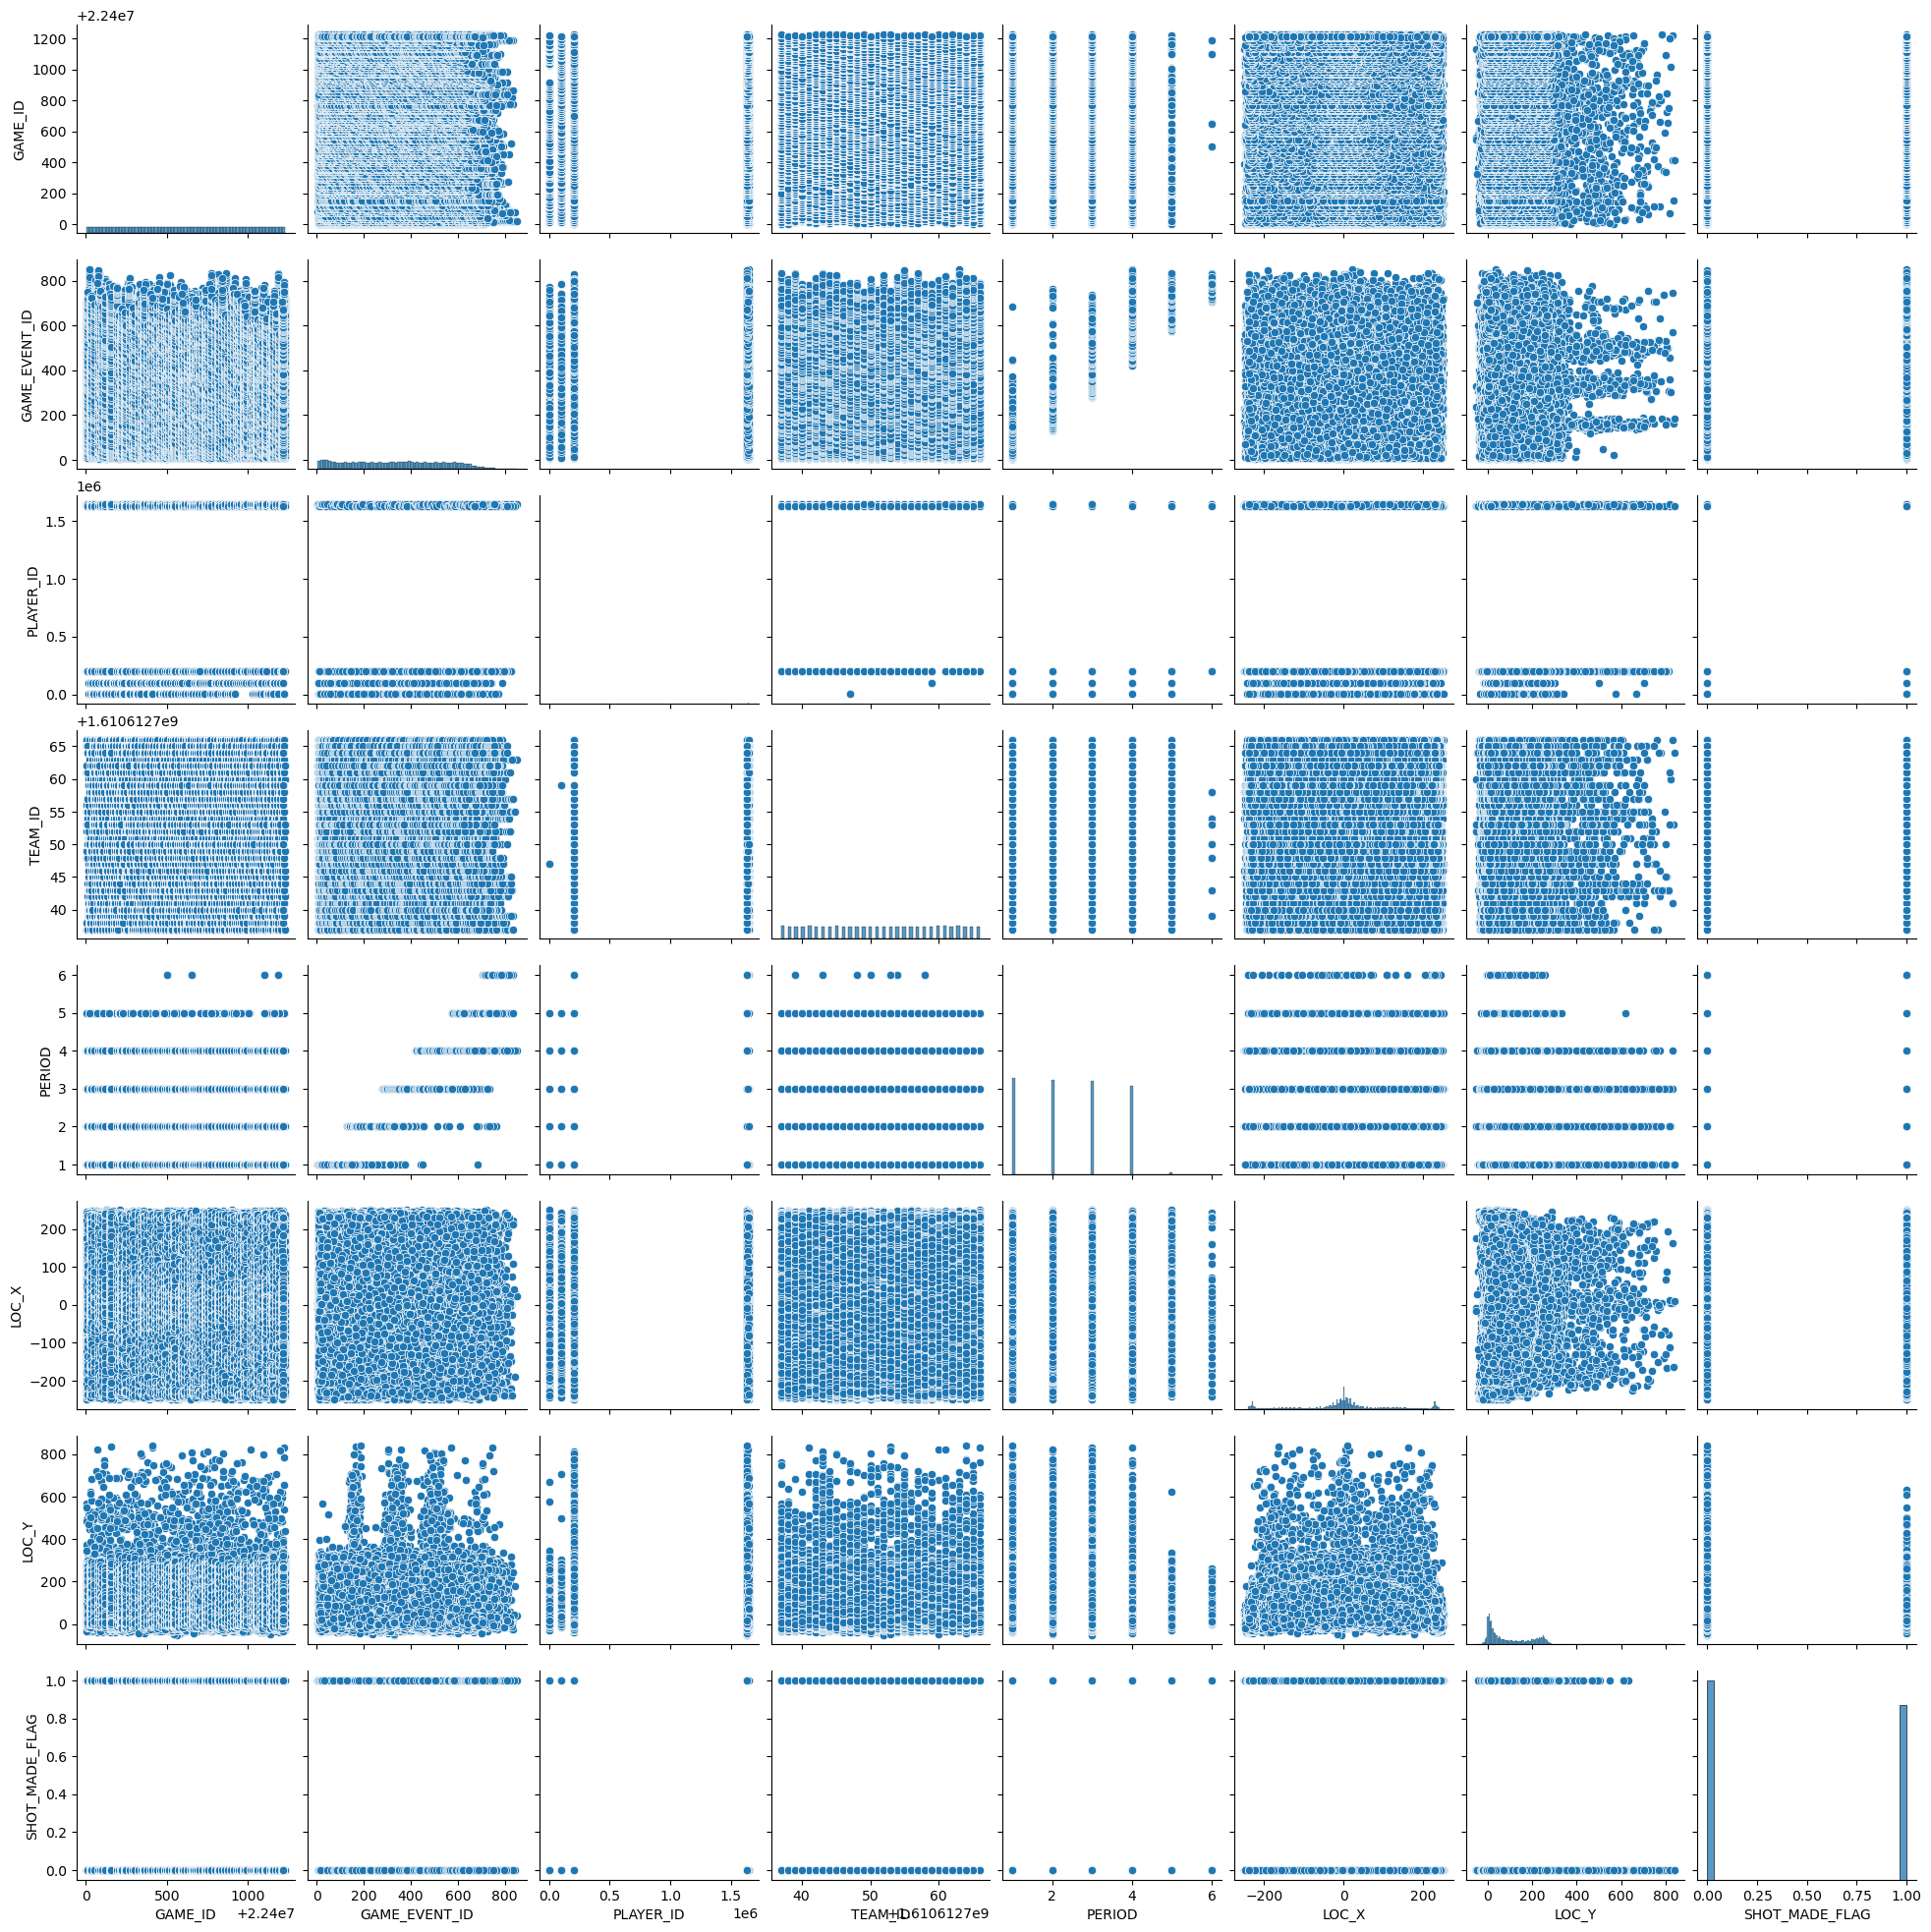

In [20]:
# Create a pairplot of the data.
sns.pairplot(df)